In [26]:
import torch
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter13_14 import muscl_reconstruction, reflective_bc
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter16 import strang_update
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter10 import HLLC_Riemann_Solver
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter6 import exact_riemann_flux
from simulation.simulator import Simulator
from CFD import create_explosion_initial_condition

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Using device: cuda
CUDA device: NVIDIA GeForce GTX 1660 SUPER


In [27]:
# reference unit
rho0 = 1.2
p0   = 1e5
u0 = (p0 / rho0)**0.5

#Constant parameters
#z, y, x
RESOLUTION = 1, 200, 200

X_DOMAIN = [0, 1] # 1 m
Y_DOMAIN = [0, 1] # 1 m
Z_DOMAIN = [0, 1] # 1 m
T_DOMAIN = [0, 1.5]
DX = (X_DOMAIN[1] - X_DOMAIN[0]) / RESOLUTION[2]
DY = (Y_DOMAIN[1] - Y_DOMAIN[0]) / RESOLUTION[1]
DZ = (Z_DOMAIN[1] - Z_DOMAIN[0]) / RESOLUTION[0]

CFL_COEFFICIENT = 0.8
GAMMA = 1.4
TOL = 1e-6

# Initial Conditions
rho_inner_phy = 1.225 #(kg/m³)
p_inner_phy = 1e7 #(pa)
rho_outer_phy = 1.225 #(kg/m³)
p_outer_phy = 101325 #(pa)

# convert to reference unit
rho_inner = rho_inner_phy / rho0
p_inner = p_inner_phy / p0
rho_outer = rho_outer_phy / rho0
p_outer = p_outer_phy / p0

sigma = 0.05

In [28]:
sim = Simulator(
    dx=DX,
    dy=DY,
    dz=DZ,
    riemann_solver=HLLC_Riemann_Solver,
    reconstruction_method=muscl_reconstruction,
    boundary_function=reflective_bc,
    update_method=strang_update,
    dimension=2
)

CELL = create_explosion_initial_condition(
    nx = RESOLUTION[2],
    ny = RESOLUTION[1],
    nz = RESOLUTION[0],
    x_domain = X_DOMAIN,
    y_domain = Y_DOMAIN,
    z_domain = Z_DOMAIN,
    rho_inner = rho_inner,
    p_inner = p_inner,
    rho_outer = rho_outer,
    p_outer = p_outer,
    sigma = sigma,
    noise = 0.08,
    device = device
)

source = CELL.clone()

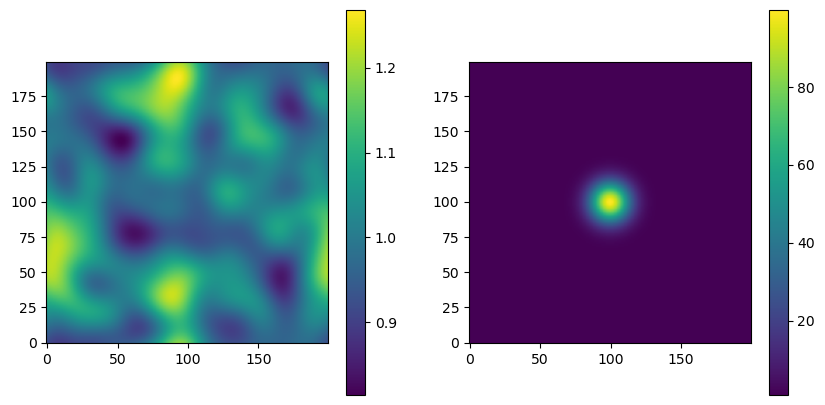

In [29]:
rho = CELL[0, :, :, 0].detach().cpu().numpy()
p = CELL[0, :, :, 4].detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

im1 = ax[0].imshow(rho, origin='lower', cmap='viridis')
im2 = ax[1].imshow(p, origin='lower', cmap='viridis')

cbar1 = fig.colorbar(im1, ax=ax[0])
cbar2 = fig.colorbar(im2, ax=ax[1])

plt.show()

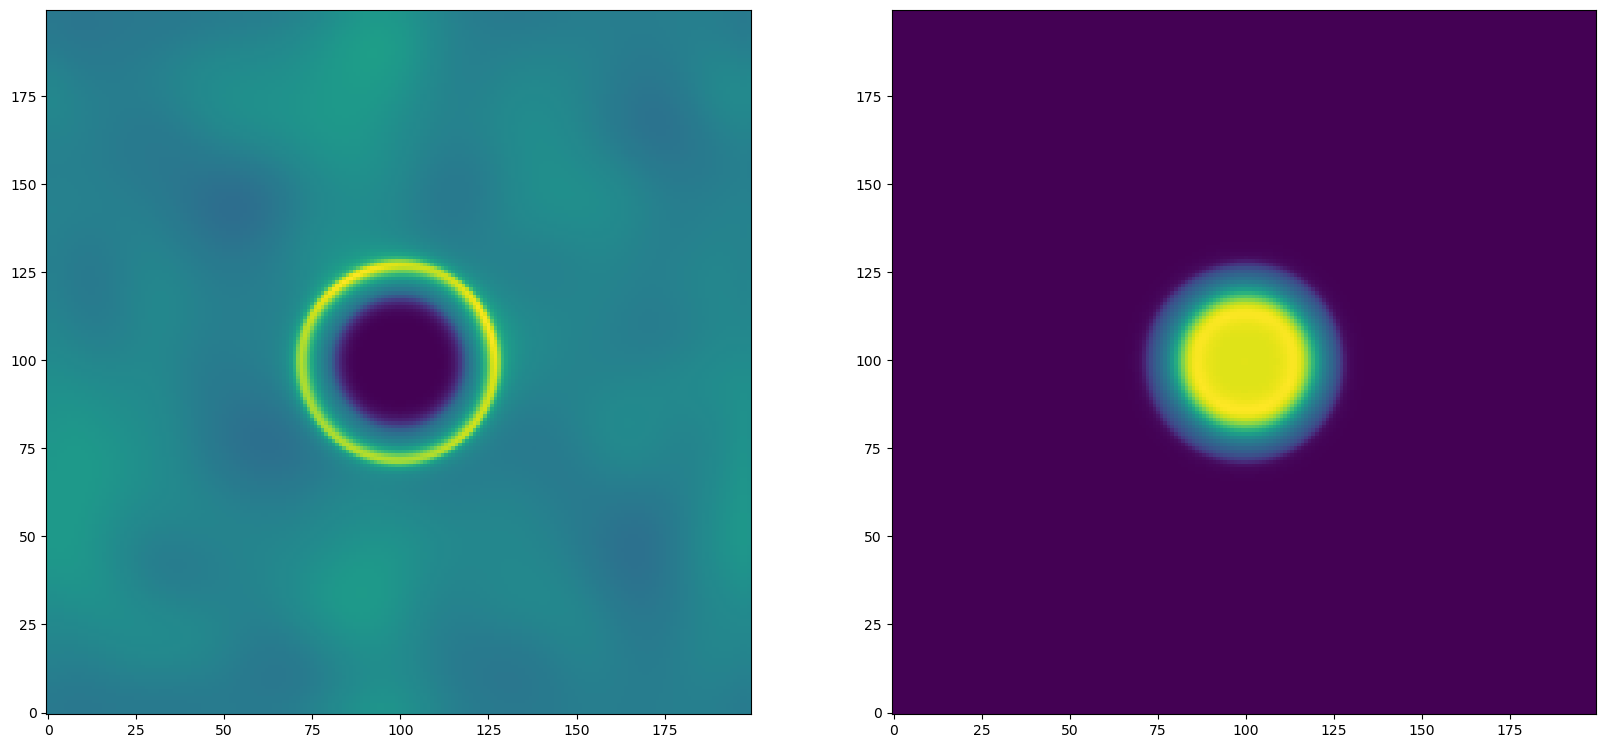

t = 0.010


In [ ]:
rho = CELL[0, :, :, 0].detach().cpu().numpy()
p = CELL[0, :, :, 4].detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

im1 = ax[0].imshow(rho, origin='lower', cmap='viridis')
im2 = ax[1].imshow(p, origin='lower', cmap='viridis')

plt.show()

t = T_DOMAIN[0]
counter = 0

while t < T_DOMAIN[1]:
    counter += 1
    CELL, dt = sim.update(CELL)
    t += dt

    #update the center rho, p to maintain the explosion
    #CELL[..., 0] = torch.max(CELL[..., 0], source[..., 0])
    CELL[..., 4] = torch.max(CELL[..., 4], source[..., 4])

    rho = CELL[0, :, :, 0].detach().cpu().numpy()
    p = CELL[0, :, :, 4].detach().cpu().numpy()

    if(counter % 10 == 0):
        im1.set_data(rho)
        im1.set_clim(rho.min(), rho.max())
        im2.set_data(p)
        im2.set_clim(p.min(), p.max())

        clear_output(wait=True) 
        display(fig)

    print(f"t = {t:.3f}")